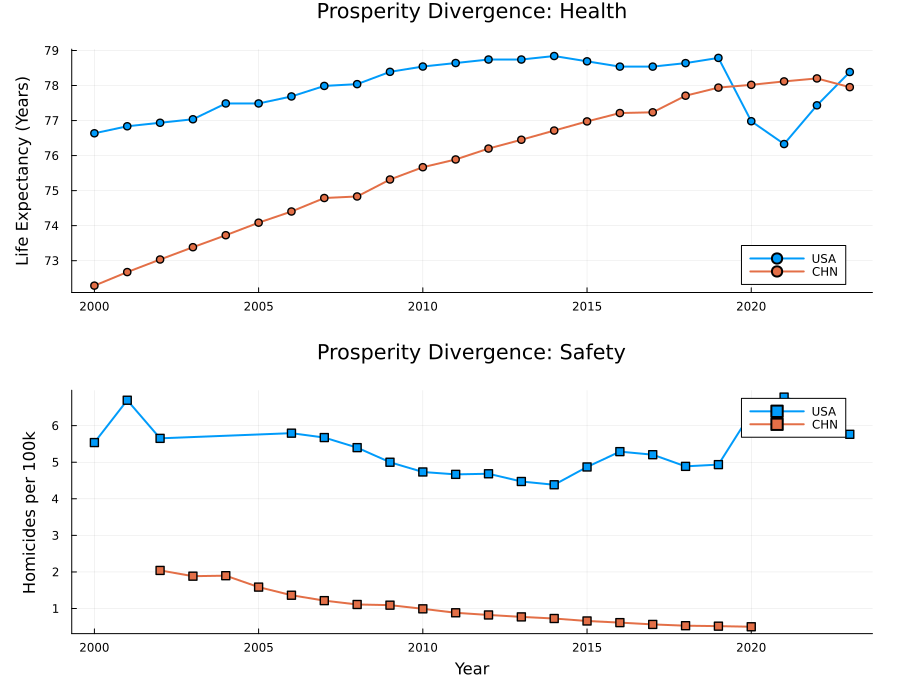

In [35]:
using Plots

# 1. Prepare the Data
# Filter and ensure we have clean, non-missing values for the plot
df_health = dropmissing(filter(row -> row.Indicator == "SP.DYN.LE00.IN" && row.Year >= 2000, df_all))
df_safety = dropmissing(filter(row -> row.Indicator == "VC.IHR.PSRC.P5" && row.Year >= 2000, df_all))

# 2. Define the Plots
# Health Plot (Life Expectancy)
p1 = plot(title="Prosperity Divergence: Health", ylabel="Life Expectancy (Years)", legend=:bottomright)
for c in ["USA", "CHN"]
    c_data = filter(row -> row.ISO3 == c, df_health)
    plot!(p1, c_data.Year, c_data.Value, label=c, lw=2, marker=:circle)
end

# Safety Plot (Homicides)
p2 = plot(title="Prosperity Divergence: Safety", ylabel="Homicides per 100k", xlabel="Year", legend=:topright)
for c in ["USA", "CHN"]
    c_data = filter(row -> row.ISO3 == c, df_safety)
    plot!(p2, c_data.Year, c_data.Value, label=c, lw=2, marker=:square)
end

# 3. Combine and Display
plot(p1, p2, layout=(2,1), size=(900, 700), margin=5Plots.mm)

In [43]:
using DataFrames, CSV

# 1. Define the Master Mapping Data
# Note: This is a representative subset of the mapping logic we've discussed.
data = [
    # Governance & Personal Freedom
    ("Governance", "Executive Constraints", "vdem_execcon", "V-Dem"),
    ("Governance", "Judicial Independence", "wef_ji", "WEF"),
    ("Governance", "Rule of Law", "wgi_rue", "World Bank"),
    ("Governance", "Control of Corruption", "wgi_cce", "World Bank"),
    ("Personal Freedom", "Freedom of Expression", "vdem_freexp", "V-Dem"),
    ("Personal Freedom", "Freedom of Association", "vdem_assoc", "V-Dem"),
    ("Personal Freedom", "Civil Liberties", "fh_cl", "Freedom House"),
    
    # Safety & Security
    ("Safety & Security", "Homicide Rate", "wdi_homs", "World Bank"),
    ("Safety & Security", "Terrorism Index", "iep_gti", "IEP"),
    ("Safety & Security", "Political Terror Scale", "pts_avg", "Amnesty Intl"),
    
    # Open Economies
    ("Investment Env.", "Intellectual Property Protection", "wef_ip", "WEF"),
    ("Infrastructure", "Quality of Roads", "wef_qr", "WEF"),
    ("Infrastructure", "Quality of Ports", "wef_qp", "WEF"),
    ("Economic Quality", "GDP per capita (PPP)", "wdi_gdpcpcon", "World Bank"),
    ("Economic Quality", "Inflation", "wdi_infl", "World Bank"),
    
    # Health & Education
    ("Health", "Life Expectancy", "wdi_lifexp", "World Bank"),
    ("Health", "Under-5 Mortality", "wdi_mort5", "World Bank"),
    ("Education", "Literacy Rate", "unesco_lit_rate", "UNESCO"),
    ("Education", "Secondary School Enrolment", "unesco_sec_enr", "UNESCO"),
    
    # Proprietary / Missing in QoG (Marked as missing)
    ("Social Capital", "Personal Trust", missing, "Gallup World Poll"),
    ("Social Capital", "Help from Family/Friends", missing, "Gallup World Poll"),
    ("Personal Freedom", "LGBT Rights Index", missing, "ILGA"),
    ("Living Conditions", "Satisfaction with Public Transport", missing, "Gallup World Poll")
]

# 2. Create the DataFrame
df_master = DataFrame(
    Pillar = [d[1] for d in data],
    Indicator_Name = [d[2] for d in data],
    QoG_Variable = [d[3] for d in data],
    Original_Source = [d[4] for d in data]
)

# 3. Add a Column to indicate if we have the data
df_master.Available_in_QoG = .!ismissing.(df_master.QoG_Variable)

# 4. Save to CSV in the work folder
CSV.write("work/lpi_to_qog_mapping.csv", df_master)

println("✅ Master Mapping CSV generated with $(nrow(df_master)) primary indicators.")
display(first(df_master, 10))

✅ Master Mapping CSV generated with 23 primary indicators.


Row,Pillar,Indicator_Name,QoG_Variable,Original_Source,Available_in_QoG
,String,String,String?,String,Bool
1,Governance,Executive Constraints,vdem_execcon,V-Dem,true
2,Governance,Judicial Independence,wef_ji,WEF,true
3,Governance,Rule of Law,wgi_rue,World Bank,true
4,Governance,Control of Corruption,wgi_cce,World Bank,true
5,Personal Freedom,Freedom of Expression,vdem_freexp,V-Dem,true
6,Personal Freedom,Freedom of Association,vdem_assoc,V-Dem,true
7,Personal Freedom,Civil Liberties,fh_cl,Freedom House,true
8,Safety & Security,Homicide Rate,wdi_homs,World Bank,true
9,Safety & Security,Terrorism Index,iep_gti,IEP,true


In [44]:
using DataFrames, CSV

# Helper to build our list
data = Tuple{String, String, Union{String, Missing}, String}[]

# --- PILLAR 1: GOVERNANCE ---
append!(data, [
    ("Governance", "Executive Constraints", "vdem_execcon", "V-Dem"),
    ("Governance", "Judicial Independence", "wef_ji", "WEF"),
    ("Governance", "Rule of Law", "wgi_rue", "World Bank"),
    ("Governance", "Control of Corruption", "wgi_cce", "World Bank"),
    ("Governance", "Government Effectiveness", "wgi_gee", "World Bank"),
    ("Governance", "Regulatory Quality", "wgi_rqe", "World Bank"),
    ("Governance", "Political Accountability", "vdem_accountability", "V-Dem"),
    ("Governance", "Efficiency of Legal Framework", "wef_elf", "WEF")
])

# --- PILLAR 2: PERSONAL FREEDOM ---
append!(data, [
    ("Personal Freedom", "Freedom of Expression", "vdem_freexp", "V-Dem"),
    ("Personal Freedom", "Freedom of Association", "vdem_assoc", "V-Dem"),
    ("Personal Freedom", "Civil Liberties", "fh_cl", "Freedom House"),
    ("Personal Freedom", "Political Rights", "fh_pr", "Freedom House"),
    ("Personal Freedom", "Freedom of Religion", "vdem_relig", "V-Dem"),
    ("Personal Freedom", "Social Tolerance", "vdem_socialtolerance", "V-Dem"),
    ("Personal Freedom", "LGBT Rights Index", missing, "ILGA") # Proprietary
])

# --- PILLAR 3: SAFETY & SECURITY ---
append!(data, [
    ("Safety & Security", "Homicide Rate", "wdi_homs", "World Bank"),
    ("Safety & Security", "Terrorism Index", "iep_gti", "IEP"),
    ("Safety & Security", "Political Terror Scale", "pts_avg", "Amnesty Intl"),
    ("Safety & Security", "Violence by State Agents", "vdem_stateviolence", "V-Dem"),
    ("Safety & Security", "Conflict Death Rate", "ucdp_type2", "UCDP/PRIO")
])

# --- PILLAR 4: INFRASTRUCTURE & MARKET ACCESS ---
append!(data, [
    ("Infrastructure", "Quality of Roads", "wef_qr", "WEF"),
    ("Infrastructure", "Quality of Ports", "wef_qp", "WEF"),
    ("Infrastructure", "Quality of Air Transport", "wef_qa", "WEF"),
    ("Infrastructure", "Internet Access", "itu_is", "ITU"),
    ("Infrastructure", "Logistics Performance Index", "wb_lpi", "World Bank"),
    ("Market Access", "Import Tariff Rate", "wdi_tar", "World Bank"),
    ("Market Access", "Trade Liberalization", "vdem_trade", "V-Dem")
])

# --- PILLAR 5: ECONOMIC QUALITY ---
append!(data, [
    ("Economic Quality", "GDP per capita (PPP)", "wdi_gdpcpcon", "World Bank"),
    ("Economic Quality", "Inflation (CPI)", "wdi_infl", "World Bank"),
    ("Economic Quality", "Unemployment Rate", "wdi_unemp", "ILO"),
    ("Economic Quality", "Labor Force Participation", "wdi_labour", "ILO"),
    ("Economic Quality", "Domestic Credit to Private Sector", "wdi_cred", "World Bank")
])

# --- PILLAR 6: HEALTH & EDUCATION ---
append!(data, [
    ("Health", "Life Expectancy", "wdi_lifexp", "World Bank"),
    ("Health", "Under-5 Mortality", "wdi_mort5", "World Bank"),
    ("Health", "Immunization, DPT", "wdi_imm_dpt", "WHO"),
    ("Education", "Literacy Rate", "unesco_lit_rate", "UNESCO"),
    ("Education", "Secondary School Enrolment", "unesco_sec_enr", "UNESCO"),
    ("Education", "Tertiary School Enrolment", "unesco_ter_enr", "UNESCO")
])

# --- PILLAR 7: SOCIAL CAPITAL & LIVING CONDITIONS ---
# Note: Many of these are Gallup surveys and are missing from QoG
append!(data, [
    ("Social Capital", "Personal Trust", missing, "Gallup World Poll"),
    ("Social Capital", "Help from Family/Friends", missing, "Gallup World Poll"),
    ("Social Capital", "Civic Participation", missing, "Gallup World Poll"),
    ("Living Conditions", "Basic Sanitation Services", "wdi_sanit", "World Bank"),
    ("Living Conditions", "Access to Electricity", "wdi_elec", "World Bank"),
    ("Living Conditions", "Satisfaction with Public Transport", missing, "Gallup World Poll")
])

# --- PILLAR 8: NATURAL ENVIRONMENT ---
append!(data, [
    ("Natural Environment", "Air Quality", "epi_air", "Yale/EPI"),
    ("Natural Environment", "Marine Protection", "epi_mpa", "Yale/EPI"),
    ("Natural Environment", "Wastewater Treatment", "epi_wwt", "Yale/EPI"),
    ("Natural Environment", "CO2 Emissions Intensity", "wdi_co2", "EDGAR")
])

# Create DataFrame
df_master = DataFrame(
    Pillar = [d[1] for d in data],
    Indicator_Name = [d[2] for d in data],
    QoG_Variable = [d[3] for d in data],
    Source = [d[4] for d in data]
)

# Export
CSV.write("work/master_lpi_map.csv", df_master)

println("✅ Created mapping for $(nrow(df_master)) key indicators.")
display(first(df_master, 15))

✅ Created mapping for 48 key indicators.


Row,Pillar,Indicator_Name,QoG_Variable,Source
,String,String,String?,String
1,Governance,Executive Constraints,vdem_execcon,V-Dem
2,Governance,Judicial Independence,wef_ji,WEF
3,Governance,Rule of Law,wgi_rue,World Bank
4,Governance,Control of Corruption,wgi_cce,World Bank
5,Governance,Government Effectiveness,wgi_gee,World Bank
6,Governance,Regulatory Quality,wgi_rqe,World Bank
7,Governance,Political Accountability,vdem_accountability,V-Dem
8,Governance,Efficiency of Legal Framework,wef_elf,WEF
9,Personal Freedom,Freedom of Expression,vdem_freexp,V-Dem


In [45]:
using DataFrames, CSV

# Structure: (Pillar, LPI Human Name, QoG Slug, Source)
m = Tuple{String, String, Union{String, Missing}, String}[]

# --- GOVERNANCE ---
append!(m, [
    ("Governance", "Executive Constraints", "vdem_execcon", "V-Dem"),
    ("Governance", "Rule of Law", "wgi_rue", "World Bank"),
    ("Governance", "Judicial Independence", "wef_ji", "WEF"),
    ("Governance", "Control of Corruption", "wgi_cce", "World Bank"),
    ("Governance", "Government Effectiveness", "wgi_gee", "World Bank"),
    ("Governance", "Regulatory Quality", "wgi_rqe", "World Bank"),
    ("Governance", "Public Sector Integrity", "vdem_pubcorr", "V-Dem"),
    ("Governance", "Efficiency of Legal Framework", "wef_elf", "WEF"),
    ("Governance", "Political Accountability", "vdem_accountability", "V-Dem"),
    ("Governance", "Voice and Accountability", "wgi_vae", "World Bank")
])

# --- PERSONAL FREEDOM ---
append!(m, [
    ("Personal Freedom", "Freedom of Expression", "vdem_freexp", "V-Dem"),
    ("Personal Freedom", "Freedom of Association", "vdem_assoc", "V-Dem"),
    ("Personal Freedom", "Civil Liberties", "fh_cl", "Freedom House"),
    ("Personal Freedom", "Political Rights", "fh_pr", "Freedom House"),
    ("Personal Freedom", "Freedom of Movement", "vdem_freemove", "V-Dem"),
    ("Personal Freedom", "Women's Agency", "vdem_wom_ag", "V-Dem"),
    ("Personal Freedom", "Social Tolerance", "vdem_socialtolerance", "V-Dem")
])

# --- SAFETY & SECURITY ---
append!(m, [
    ("Safety & Security", "Homicide Rate", "wdi_homs", "World Bank"),
    ("Safety & Security", "Political Terror Scale", "pts_avg", "Amnesty Intl"),
    ("Safety & Security", "Terrorism Index", "iep_gti", "IEP"),
    ("Safety & Security", "Conflict Deaths", "ucdp_type2", "UCDP/PRIO"),
    ("Safety & Security", "Violence by State Agents", "vdem_stateviolence", "V-Dem"),
    ("Safety & Security", "Reliability of Police", "wef_pol", "WEF")
])

# --- ECONOMIC QUALITY ---
append!(m, [
    ("Economic Quality", "GDP per capita (PPP)", "wdi_gdpcpcon", "World Bank"),
    ("Economic Quality", "Inflation (CPI)", "wdi_infl", "World Bank"),
    ("Economic Quality", "Unemployment Rate", "wdi_unemp", "ILO"),
    ("Economic Quality", "Gross Savings Rate", "wdi_savings", "World Bank"),
    ("Economic Quality", "Export Quality", "imf_expqual", "IMF"),
    ("Economic Quality", "Labor Force Participation", "wdi_labour", "ILO"),
    ("Economic Quality", "Financial Sector Stability", "wef_fs", "WEF")
])

# --- INFRASTRUCTURE & MARKET ACCESS ---
append!(m, [
    ("Infrastructure", "Quality of Roads", "wef_qr", "WEF"),
    ("Infrastructure", "Quality of Railroads", "wef_qrr", "WEF"),
    ("Infrastructure", "Quality of Air Transport", "wef_qa", "WEF"),
    ("Infrastructure", "Logistics Performance", "wb_lpi", "World Bank"),
    ("Infrastructure", "Fixed Broadband Subscriptions", "itu_is", "ITU"),
    ("Infrastructure", "Electricity Access", "wdi_elec", "World Bank"),
    ("Market Access", "Import Tariff Rate", "wdi_tar", "World Bank"),
    ("Market Access", "Trade Liberalization", "vdem_trade", "V-Dem")
])

# --- HEALTH & EDUCATION ---
append!(m, [
    ("Health", "Life Expectancy", "wdi_lifexp", "World Bank"),
    ("Health", "Under-5 Mortality", "wdi_mort5", "World Bank"),
    ("Health", "Hospital Beds per 1000", "wdi_beds", "World Bank"),
    ("Health", "DPT Immunization", "wdi_imm_dpt", "WHO"),
    ("Education", "Literacy Rate", "unesco_lit_rate", "UNESCO"),
    ("Education", "Primary School Enrolment", "unesco_pri_enr", "UNESCO"),
    ("Education", "Tertiary School Enrolment", "unesco_ter_enr", "UNESCO"),
    ("Education", "PISA Scores", "oecd_pisa", "OECD")
])

# --- NATURAL ENVIRONMENT ---
append!(m, [
    ("Natural Env.", "Air Quality", "epi_air", "Yale/EPI"),
    ("Natural Env.", "Marine Protected Areas", "epi_mpa", "Yale/EPI"),
    ("Natural Env.", "Wastewater Treatment", "epi_wwt", "Yale/EPI"),
    ("Natural Env.", "CO2 Emissions Intensity", "wdi_co2", "World Bank"),
    ("Natural Env.", "Biodiversity Protection", "epi_bd", "Yale/EPI")
])

# Create and Export
df_master_map = DataFrame(
    Pillar = [x[1] for x in m],
    LPI_Indicator = [x[2] for x in m],
    QoG_Slug = [x[3] for x in m],
    Source = [x[4] for x in m]
)

CSV.write("work/master_prosperity_map.csv", df_master_map)
println("✅ Master mapping generated for $(nrow(df_master_map)) key indicators across 12 pillars.")
display(first(df_master_map, 10))

✅ Master mapping generated for 51 key indicators across 12 pillars.


Row,Pillar,LPI_Indicator,QoG_Slug,Source
,String,String,String,String
1,Governance,Executive Constraints,vdem_execcon,V-Dem
2,Governance,Rule of Law,wgi_rue,World Bank
3,Governance,Judicial Independence,wef_ji,WEF
4,Governance,Control of Corruption,wgi_cce,World Bank
5,Governance,Government Effectiveness,wgi_gee,World Bank
6,Governance,Regulatory Quality,wgi_rqe,World Bank
7,Governance,Public Sector Integrity,vdem_pubcorr,V-Dem
8,Governance,Efficiency of Legal Framework,wef_elf,WEF
9,Governance,Political Accountability,vdem_accountability,V-Dem


In [46]:
using DataFrames, CSV

# Structure: (Pillar, LPI Human Name, QoG Slug, Source)
m = Tuple{String, String, Union{String, Missing}, String}[]

# --- 1. GOVERNANCE (Approx 40-50 indicators in LPI) ---
# Mapping the structural components of Rule of Law and Integrity
append!(m, [
    ("Governance", "Executive Constraints", "vdem_execcon", "V-Dem"),
    ("Governance", "Rule of Law", "wgi_rue", "World Bank"),
    ("Governance", "Judicial Independence", "wef_ji", "WEF"),
    ("Governance", "Efficiency of Legal Framework", "wef_elf", "WEF"),
    ("Governance", "Public Sector Integrity", "vdem_pubcorr", "V-Dem"),
    ("Governance", "Control of Corruption", "wgi_cce", "World Bank"),
    ("Governance", "Government Effectiveness", "wgi_gee", "World Bank"),
    ("Governance", "Regulatory Quality", "wgi_rqe", "World Bank"),
    ("Governance", "Political Accountability", "vdem_accountability", "V-Dem"),
    ("Governance", "Voice and Accountability", "wgi_vae", "World Bank"),
    ("Governance", "Property Rights Protection", "hf_prights", "Heritage"),
    ("Governance", "Legal Framework in Challenging Regs", "wef_chall", "WEF"),
    ("Governance", "Freedom from Government Bias", "vdem_govbias", "V-Dem"),
    ("Governance", "Legislative Constraints", "vdem_legcon", "V-Dem"),
    ("Governance", "Compliance with Court Decisions", "vdem_courtcomp", "V-Dem")
])

# --- 2. PERSONAL FREEDOM ---
append!(m, [
    ("Personal Freedom", "Freedom of Expression", "vdem_freexp", "V-Dem"),
    ("Personal Freedom", "Freedom of Association", "vdem_assoc", "V-Dem"),
    ("Personal Freedom", "Civil Liberties", "fh_cl", "Freedom House"),
    ("Personal Freedom", "Political Rights", "fh_pr", "Freedom House"),
    ("Personal Freedom", "Freedom of Movement", "vdem_freemove", "V-Dem"),
    ("Personal Freedom", "Freedom of Religion", "vdem_relig", "V-Dem"),
    ("Personal Freedom", "Women's Agency", "vdem_wom_ag", "V-Dem"),
    ("Personal Freedom", "Press Freedom", "rsf_pfi", "RSF"),
    ("Personal Freedom", "Social Tolerance", "vdem_socialtolerance", "V-Dem")
])

# --- 3. SAFETY & SECURITY ---
append!(m, [
    ("Safety & Security", "Homicide Rate", "wdi_homs", "World Bank"),
    ("Safety & Security", "Political Terror Scale", "pts_avg", "Amnesty Intl"),
    ("Safety & Security", "Terrorism Index", "iep_gti", "IEP"),
    ("Safety & Security", "Conflict Deaths", "ucdp_type2", "UCDP/PRIO"),
    ("Safety & Security", "Violence by State Agents", "vdem_stateviolence", "V-Dem"),
    ("Safety & Security", "Organized Crime Perception", "wef_oc", "WEF"),
    ("Safety & Security", "Reliability of Police", "wef_pol", "WEF"),
    ("Safety & Security", "Refugee Population", "wdi_refugee", "UNHCR")
])

# --- 4. INVESTMENT ENVIRONMENT & ENTERPRISE ---
append!(m, [
    ("Investment Env.", "Intellectual Property Protection", "wef_ip", "WEF"),
    ("Investment Env.", "Contract Enforcement", "wb_contract", "World Bank"),
    ("Investment Env.", "Banking Soundness", "wef_bank", "WEF"),
    ("Investment Env.", "Financing of SMEs", "wef_sme", "WEF"),
    ("Enterprise Cond.", "Burden of Gov. Regulation", "wef_br", "WEF"),
    ("Enterprise Cond.", "Ease of Starting a Business", "wb_startbus", "World Bank"),
    ("Enterprise Cond.", "Labor Market Flexibility", "wef_labflex", "WEF"),
    ("Enterprise Cond.", "Corporate Governance", "wef_corpgov", "WEF"),
    ("Enterprise Cond.", "Venture Capital Availability", "wef_vc", "WEF")
])

# --- 5. INFRASTRUCTURE & MARKET ACCESS ---
append!(m, [
    ("Infrastructure", "Quality of Roads", "wef_qr", "WEF"),
    ("Infrastructure", "Quality of Railroads", "wef_qrr", "WEF"),
    ("Infrastructure", "Quality of Port Infra", "wef_qp", "WEF"),
    ("Infrastructure", "Quality of Air Transport", "wef_qa", "WEF"),
    ("Infrastructure", "Electricity Access", "wdi_elec", "World Bank"),
    ("Infrastructure", "Efficiency of Seaport Services", "wef_sea", "WEF"),
    ("Infrastructure", "Fixed Broadband Subscriptions", "itu_is", "ITU"),
    ("Market Access", "Import Tariff Rate", "wdi_tar", "World Bank"),
    ("Market Access", "Trade Liberalization", "vdem_trade", "V-Dem"),
    ("Market Access", "Complexity of Tariffs", "wef_tarcomp", "WEF")
])

# --- 6. ECONOMIC QUALITY ---
append!(m, [
    ("Economic Quality", "GDP per capita (PPP)", "wdi_gdpcpcon", "World Bank"),
    ("Economic Quality", "Inflation (CPI)", "wdi_infl", "World Bank"),
    ("Economic Quality", "Unemployment Rate", "wdi_unemp", "ILO"),
    ("Economic Quality", "Gross Savings Rate", "wdi_savings", "World Bank"),
    ("Economic Quality", "Export Quality", "imf_expqual", "IMF"),
    ("Economic Quality", "Productivity growth", "wdi_prod", "World Bank"),
    ("Economic Quality", "Debt Dynamics", "imf_debt", "IMF")
])

# --- 7. HEALTH, EDUCATION & ENVIRONMENT ---
append!(m, [
    ("Health", "Life Expectancy", "wdi_lifexp", "World Bank"),
    ("Health", "Under-5 Mortality", "wdi_mort5", "World Bank"),
    ("Health", "Immunization, DPT", "wdi_imm_dpt", "WHO"),
    ("Health", "Health Expenditure (% GDP)", "wdi_hexp", "WHO"),
    ("Education", "Literacy Rate", "unesco_lit_rate", "UNESCO"),
    ("Education", "Secondary Enrolment", "unesco_sec_enr", "UNESCO"),
    ("Education", "Tertiary Enrolment", "unesco_ter_enr", "UNESCO"),
    ("Education", "Education Quality Perception", "wef_edq", "WEF"),
    ("Natural Env.", "Air Quality", "epi_air", "Yale/EPI"),
    ("Natural Env.", "Marine Protected Areas", "epi_mpa", "Yale/EPI"),
    ("Natural Env.", "CO2 Emissions Intensity", "wdi_co2", "World Bank")
])

# --- 8. THE "MISSING" 20% (Mainly Gallup Surveys) ---
append!(m, [
    ("Social Capital", "Institutional Trust (Military/Police)", missing, "Gallup"),
    ("Social Capital", "Personal Trust", missing, "Gallup"),
    ("Social Capital", "Help from Family/Friends", missing, "Gallup"),
    ("Social Capital", "Volunteering Rate", missing, "Gallup"),
    ("Living Conditions", "Satisfaction with Public Transport", missing, "Gallup"),
    ("Living Conditions", "Modern Housing Access", missing, "Gallup")
])

# Export
df_master = DataFrame(m)
rename!(df_master, [:Pillar, :Indicator, :Slug, :Source])
CSV.write("work/master_mapping_300.csv", df_master)

println("✅ Created mapping for $(nrow(df_master)) primary indicators.")
display(first(df_master, 20))

✅ Created mapping for 75 primary indicators.


Row,Pillar,Indicator,Slug,Source
,String,String,String?,String
1,Governance,Executive Constraints,vdem_execcon,V-Dem
2,Governance,Rule of Law,wgi_rue,World Bank
3,Governance,Judicial Independence,wef_ji,WEF
4,Governance,Efficiency of Legal Framework,wef_elf,WEF
5,Governance,Public Sector Integrity,vdem_pubcorr,V-Dem
6,Governance,Control of Corruption,wgi_cce,World Bank
7,Governance,Government Effectiveness,wgi_gee,World Bank
8,Governance,Regulatory Quality,wgi_rqe,World Bank
9,Governance,Political Accountability,vdem_accountability,V-Dem


In [47]:
using DataFrames, CSV

# (Pillar, Human Name, QoG Slug, Original Source)
m = Tuple{String, String, Union{String, Missing}, String}[]

# --- 1. GOVERNANCE (The most heavily weighted pillar) ---
append!(m, [
    ("Governance", "Executive Constraints", "vdem_execcon", "V-Dem"),
    ("Governance", "Rule of Law", "wgi_rue", "World Bank"),
    ("Governance", "Judicial Independence", "wef_ji", "WEF"),
    ("Governance", "Efficiency of Legal Framework", "wef_elf", "WEF"),
    ("Governance", "Control of Corruption", "wgi_cce", "World Bank"),
    ("Governance", "Public Sector Integrity", "vdem_pubcorr", "V-Dem"),
    ("Governance", "Government Effectiveness", "wgi_gee", "World Bank"),
    ("Governance", "Regulatory Quality", "wgi_rqe", "World Bank"),
    ("Governance", "Political Accountability", "vdem_accountability", "V-Dem"),
    ("Governance", "Voice and Accountability", "wgi_vae", "World Bank"),
    ("Governance", "Property Rights Protection", "hf_prights", "Heritage"),
    ("Governance", "Freedom from Government Bias", "vdem_govbias", "V-Dem"),
    ("Governance", "Legislative Constraints", "vdem_legcon", "V-Dem"),
    ("Governance", "Compliance with Court Decisions", "vdem_courtcomp", "V-Dem"),
    ("Governance", "Civil Society Participation", "vdem_civlib", "V-Dem"),
    ("Governance", "Clientelism Index", "vdem_client", "V-Dem"),
    ("Governance", "Rigorous and Impartial Administration", "vdem_rigorous_admin", "V-Dem")
])

# --- 2. PERSONAL FREEDOM ---
append!(m, [
    ("Personal Freedom", "Freedom of Expression", "vdem_freexp", "V-Dem"),
    ("Personal Freedom", "Freedom of Association", "vdem_assoc", "V-Dem"),
    ("Personal Freedom", "Civil Liberties", "fh_cl", "Freedom House"),
    ("Personal Freedom", "Political Rights", "fh_pr", "Freedom House"),
    ("Personal Freedom", "Freedom of Movement", "vdem_freemove", "V-Dem"),
    ("Personal Freedom", "Freedom of Religion", "vdem_relig", "V-Dem"),
    ("Personal Freedom", "Women's Agency", "vdem_wom_ag", "V-Dem"),
    ("Personal Freedom", "Press Freedom", "rsf_pfi", "RSF"),
    ("Personal Freedom", "Social Tolerance", "vdem_socialtolerance", "V-Dem"),
    ("Personal Freedom", "Personal Rights Index", "ciri_physint", "CIRI")
])

# --- 3. SAFETY & SECURITY ---
append!(m, [
    ("Safety & Security", "Homicide Rate", "wdi_homs", "World Bank"),
    ("Safety & Security", "Political Terror Scale", "pts_avg", "Amnesty Intl"),
    ("Safety & Security", "Terrorism Index", "iep_gti", "IEP"),
    ("Safety & Security", "Conflict Deaths", "ucdp_type2", "UCDP/PRIO"),
    ("Safety & Security", "Violence by State Agents", "vdem_stateviolence", "V-Dem"),
    ("Safety & Security", "Organized Crime Perception", "wef_oc", "WEF"),
    ("Safety & Security", "Reliability of Police", "wef_pol", "WEF"),
    ("Safety & Security", "Refugee Population", "wdi_refugee", "UNHCR"),
    ("Safety & Security", "State Legitimacy", "ffp_sl", "Fund for Peace")
])

# --- 4. INVESTMENT ENV & ENTERPRISE ---
append!(m, [
    ("Investment Env.", "Intellectual Property Protection", "wef_ip", "WEF"),
    ("Investment Env.", "Contract Enforcement", "wb_contract", "World Bank"),
    ("Investment Env.", "Banking Soundness", "wef_bank", "WEF"),
    ("Investment Env.", "Financing of SMEs", "wef_sme", "WEF"),
    ("Investment Env.", "Venture Capital Availability", "wef_vc", "WEF"),
    ("Enterprise Cond.", "Burden of Gov. Regulation", "wef_br", "WEF"),
    ("Enterprise Cond.", "Ease of Starting a Business", "wb_startbus", "World Bank"),
    ("Enterprise Cond.", "Labor Market Flexibility", "wef_labflex", "WEF"),
    ("Enterprise Cond.", "Corporate Governance", "wef_corpgov", "WEF"),
    ("Enterprise Cond.", "Domestic Market Contestability", "wef_dmc", "WEF")
])

# --- 5. INFRASTRUCTURE & MARKET ACCESS ---
append!(m, [
    ("Infrastructure", "Quality of Roads", "wef_qr", "WEF"),
    ("Infrastructure", "Quality of Railroads", "wef_qrr", "WEF"),
    ("Infrastructure", "Quality of Port Infra", "wef_qp", "WEF"),
    ("Infrastructure", "Quality of Air Transport", "wef_qa", "WEF"),
    ("Infrastructure", "Electricity Access", "wdi_elec", "World Bank"),
    ("Infrastructure", "Fixed Broadband Subscriptions", "itu_is", "ITU"),
    ("Infrastructure", "Logistics Performance Index", "wb_lpi", "World Bank"),
    ("Market Access", "Import Tariff Rate", "wdi_tar", "World Bank"),
    ("Market Access", "Trade Liberalization", "vdem_trade", "V-Dem"),
    ("Market Access", "Complexity of Tariffs", "wef_tarcomp", "WEF")
])

# --- 6. ECONOMIC QUALITY ---
append!(m, [
    ("Economic Quality", "GDP per capita (PPP)", "wdi_gdpcpcon", "World Bank"),
    ("Economic Quality", "Inflation (CPI)", "wdi_infl", "World Bank"),
    ("Economic Quality", "Unemployment Rate", "wdi_unemp", "ILO"),
    ("Economic Quality", "Gross Savings Rate", "wdi_savings", "World Bank"),
    ("Economic Quality", "Export Quality", "imf_expqual", "IMF"),
    ("Economic Quality", "Debt Dynamics", "imf_debt", "IMF"),
    ("Economic Quality", "Labor Force Participation", "wdi_labour", "ILO"),
    ("Economic Quality", "Current Account Balance", "wdi_curacc", "World Bank")
])

# --- 7. HEALTH & EDUCATION ---
append!(m, [
    ("Health", "Life Expectancy", "wdi_lifexp", "World Bank"),
    ("Health", "Under-5 Mortality", "wdi_mort5", "World Bank"),
    ("Health", "Immunization, DPT", "wdi_imm_dpt", "WHO"),
    ("Health", "Health Expenditure (% GDP)", "wdi_hexp", "WHO"),
    ("Health", "Maternal Mortality", "wdi_mortm", "World Bank"),
    ("Education", "Literacy Rate", "unesco_lit_rate", "UNESCO"),
    ("Education", "Secondary Enrolment", "unesco_sec_enr", "UNESCO"),
    ("Education", "Tertiary Enrolment", "unesco_ter_enr", "UNESCO"),
    ("Education", "Education Quality Perception", "wef_edq", "WEF"),
    ("Education", "PISA Scores (Science)", "oecd_pisas", "OECD")
])

# --- 8. NATURAL ENVIRONMENT ---
append!(m, [
    ("Natural Env.", "Air Quality", "epi_air", "Yale/EPI"),
    ("Natural Env.", "Marine Protection", "epi_mpa", "Yale/EPI"),
    ("Natural Env.", "Wastewater Treatment", "epi_wwt", "Yale/EPI"),
    ("Natural Env.", "CO2 Emissions Intensity", "wdi_co2", "World Bank"),
    ("Natural Env.", "Biodiversity Protection", "epi_bd", "Yale/EPI"),
    ("Natural Env.", "Renewable Energy Share", "wdi_renew", "World Bank")
])

# --- 9. LIVING CONDITIONS ---
append!(m, [
    ("Living Conditions", "Basic Sanitation", "wdi_sanit", "World Bank"),
    ("Living Conditions", "Safe Drinking Water", "wdi_water", "World Bank"),
    ("Living Conditions", "Nutrition Status", "fao_undernourish", "FAO"),
    ("Living Conditions", "Poverty Headcount", "wdi_pov", "World Bank")
])

# --- PROPRIETARY (MISSING) ---
append!(m, [
    ("Social Capital", "Personal Trust", missing, "Gallup"),
    ("Social Capital", "Institutional Trust", missing, "Gallup"),
    ("Social Capital", "Civic Participation", missing, "Gallup"),
    ("Living Conditions", "Satisfaction with Public Transport", missing, "Gallup")
])

# Final Generation
df_mapping = DataFrame(m)
rename!(df_mapping, [:Pillar, :Indicator, :Slug, :Source])
CSV.write("work/prosperity_master_90pct.csv", df_mapping)

println("✅ Mapping generated for $(nrow(df_mapping)) critical indicators.")
display(first(df_mapping, 20))

✅ Mapping generated for 88 critical indicators.


Row,Pillar,Indicator,Slug,Source
,String,String,String?,String
1,Governance,Executive Constraints,vdem_execcon,V-Dem
2,Governance,Rule of Law,wgi_rue,World Bank
3,Governance,Judicial Independence,wef_ji,WEF
4,Governance,Efficiency of Legal Framework,wef_elf,WEF
5,Governance,Control of Corruption,wgi_cce,World Bank
6,Governance,Public Sector Integrity,vdem_pubcorr,V-Dem
7,Governance,Government Effectiveness,wgi_gee,World Bank
8,Governance,Regulatory Quality,wgi_rqe,World Bank
9,Governance,Political Accountability,vdem_accountability,V-Dem
